# Evaluación Parcial 1 — Exploración y Preprocesamiento de Datos
**Machine Learning TLY1101**

**Integrantes del grupo:** Karla Hoch y Sebastián Huaiquimilla

**Caso:** Caso 3 — Análisis de Popularidad de Canciones en Spotify

## Contexto de negocio
Una plataforma de streaming desea comprender qué características musicales influyen en la popularidad de las canciones, para apoyar estrategias de recomendación y promoción.

## Objetivo del proyecto
Preparar el conjunto de datos de canciones de Spotify (características de audio, género y popularidad) mediante un preprocesamiento integral, dejándolo listo para entrenar modelos de Machine Learning que respondan a las preguntas de negocio:
- ¿Qué variables influyen en la popularidad?
- ¿Es posible clasificar canciones según su popularidad?
- ¿Qué patrones presentan los distintos géneros?

**Fuente del dataset:** [Spotify Tracks Dataset — Kaggle](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

## 0. Importación de librerías a utilizar

Se importan las librerías necesarias para el análisis y preprocesamiento de datos: `pandas` y `numpy` para manipulación de datos, `matplotlib` para visualizaciones, y `scikit-learn` para las técnicas de escalamiento.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

## 1. Descripción general del conjunto de datos

El dataset contiene **114.000 canciones** de Spotify, con **21 variables**. Cada fila representa una canción etiquetada bajo un género específico (una misma canción puede aparecer varias veces si Spotify la clasifica en más de un género).

In [7]:
df = pd.read_csv('../data/raw/Spotify_Tracks_Dataset.csv')
print(df.shape)
df.head()

(114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

**Significado de las variables principales:**

| Variable | Descripción |
|---|---|
| `popularity` | Puntaje 0-100 asignado por Spotify (variable objetivo) |
| `duration_ms` | Duración de la canción en milisegundos |
| `explicit` | Si la canción tiene contenido explícito (booleano) |
| `danceability`, `energy`, `valence` | Puntajes 0-1 sobre qué tan bailable, enérgica o "positiva" suena la canción |
| `loudness` | Volumen promedio en decibeles (negativo, valores más cercanos a 0 = más fuerte) |
| `key` | Tonalidad musical (0=Do, 1=Do#, ..., 11=Si) — categórica nominal, aunque venga como número |
| `mode` | Modo musical: 1=Mayor, 0=Menor |
| `speechiness`, `acousticness`, `instrumentalness`, `liveness` | Puntajes 0-1 sobre presencia de voz hablada, sonido acústico, ausencia de voz, y presencia de público en vivo |
| `tempo` | Velocidad en BPM (beats por minuto) |
| `track_genre` | Género musical asignado (114 categorías distintas) |

Las columnas `Unnamed: 0`, `track_id`, `track_name`, `album_name` y `artists` son **identificadores o texto libre**: no aportan valor numérico directo al modelo (y el caso indica que no se debe hacer procesamiento de texto/NLP), por lo que se dejarán solo como referencia y no se usarán como variables predictoras.

In [9]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 2. Selección de características relevantes

Como primer filtro, se eliminan las columnas que son identificadores o texto libre no utilizable sin NLP. Se guarda una copia con `track_id`, `track_name` y `artists` aparte, por si se necesitan más adelante para revisar casos puntuales.

In [10]:
referencia = df[['track_id', 'track_name', 'artists']].copy()

df = df.drop(columns=['Unnamed: 0', 'track_id', 'track_name', 'album_name', 'artists'])
df.columns.tolist()

['popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'track_genre']

## 3. Detección y gestión de valores faltantes y atípicos

### 3.1 Valores faltantes

In [11]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

Tras eliminar las columnas de texto en el paso anterior, no quedan valores faltantes "explícitos" (NaN) en el dataset — el único registro que tenía nulos, los tenía justamente en `artists`, `album_name` y `track_name`, columnas ya descartadas. Sin embargo, esto no significa que el dataset esté libre de datos problemáticos: a continuación revisamos si hay valores faltantes "disfrazados" como ceros.

### 3.2 Valor faltante "disfrazado": tempo = 0

Antes de buscar outliers, revisamos un caso especial: el tempo (BPM) de una canción **no puede ser realmente 0** — ninguna canción tiene velocidad cero. Es más probable que sea un valor que Spotify no pudo calcular y quedó registrado como 0, es decir, un MV disfrazado de número.

In [12]:
print("Canciones con tempo = 0:", (df['tempo'] == 0).sum())
print("Canciones con duration_ms = 0:", (df['duration_ms'] == 0).sum())

Canciones con tempo = 0: 157
Canciones con duration_ms = 0: 1


Hay **157 canciones con tempo = 0** (0,14% del dataset) y **1 canción con duración 0 ms**. Ambos son imposibles en la realidad, así que se tratan como MV: se reemplazan por `NaN` y luego se imputan con la **mediana** de la variable (se prefiere mediana sobre media porque, como veremos, el tempo y la duración pueden tener outliers que distorsionan el promedio).

In [13]:
df.loc[df['tempo'] == 0, 'tempo'] = np.nan
df.loc[df['duration_ms'] == 0, 'duration_ms'] = np.nan

df['tempo'] = df['tempo'].fillna(df['tempo'].median())
df['duration_ms'] = df['duration_ms'].fillna(df['duration_ms'].median())

print("Quedan tempo=NaN:", df['tempo'].isnull().sum())
print("Quedan duration_ms=NaN:", df['duration_ms'].isnull().sum())

Quedan tempo=NaN: 0
Quedan duration_ms=NaN: 0


### 3.3 Detección de valores atípicos (IQR)

In [14]:
def resumen_outliers_iqr(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    return len(outliers), round(len(outliers)/len(serie)*100, 2), lim_inf, lim_sup

cols_numericas = ['duration_ms','danceability','energy','loudness','speechiness',
                   'acousticness','instrumentalness','liveness','valence','tempo']

for col in cols_numericas:
    n, pct, lo, hi = resumen_outliers_iqr(df[col])
    print(f"{col}: {n} outliers ({pct}%) | límites=[{lo:.2f}, {hi:.2f}]")

duration_ms: 5616 outliers (4.93%) | límites=[42906.00, 392666.00]
danceability: 620 outliers (0.54%) | límites=[0.10, 1.05]
energy: 0 outliers (0.0%) | límites=[-0.10, 1.43]
loudness: 6173 outliers (5.41%) | límites=[-17.53, 2.51]
speechiness: 13211 outliers (11.59%) | límites=[-0.04, 0.16]
acousticness: 0 outliers (0.0%) | límites=[-0.85, 1.47]
instrumentalness: 25246 outliers (22.15%) | límites=[-0.07, 0.12]
liveness: 8642 outliers (7.58%) | límites=[-0.16, 0.54]
valence: 0 outliers (0.0%) | límites=[-0.37, 1.32]
tempo: 475 outliers (0.42%) | límites=[38.63, 200.94]


### 3.4 Visualización de valores atípicos con boxplots

Antes de decidir qué hacer con los outliers detectados por IQR, los visualizamos con boxplots para respaldar la decisión con evidencia gráfica, no solo con números.

/tmp/ipykernel_23460/1955541747.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True)
/tmp/ipykernel_23460/1955541747.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True)
/tmp/ipykernel_23460/1955541747.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True)
/tmp/ipykernel_23460/1955541747.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True)
/tmp/ipykernel_23460/1955541747.py:5: MatplotlibDepr

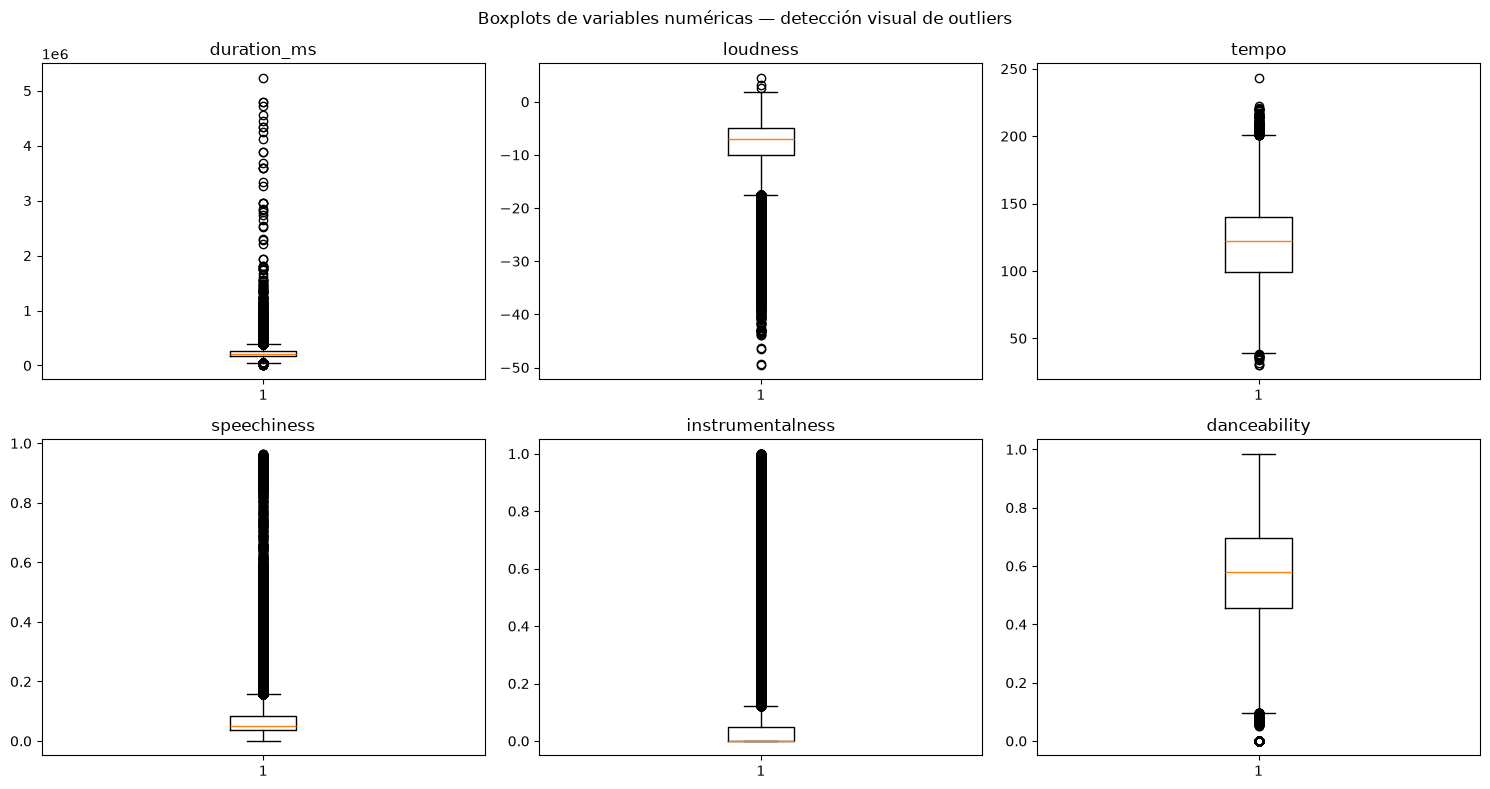

In [15]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
cols_a_graficar = ['duration_ms', 'loudness', 'tempo', 'speechiness', 'instrumentalness', 'danceability']

for ax, col in zip(axs.flat, cols_a_graficar):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)

plt.suptitle('Boxplots de variables numéricas — detección visual de outliers')
plt.tight_layout()
plt.show()

**Decisión de tratamiento:**

- `speechiness` (11,6%), `instrumentalness` (22,2%) y `liveness` (7,6%) muestran un "% de outliers" muy alto según IQR, pero esto es un **efecto esperado del método sobre variables acotadas entre 0 y 1 con distribución muy sesgada** (la mayoría de las canciones tiene valores bajos, y unas pocas —instrumentales, en vivo, habladas— tienen valores altos). Esos valores **no son errores**, son la naturaleza real de la variable: una canción 100% instrumental es un caso válido, no un dato corrupto. **Se conservan sin modificar.**
- `duration_ms` (4,93%) y `loudness` (5,41%) sí tienen outliers "clásicos": canciones muy largas/cortas o muy fuertes/silenciosas. Aquí **sí aplicamos un tratamiento** (capping o winsorización) en la siguiente celda, para limitar el efecto de los casos más extremos sin perder por completo esos registros.
- `danceability` (0,54%) y `tempo` (0,42%) tienen muy pocos outliers — se conservan tal cual, no justifica un tratamiento especial.

In [16]:
def aplicar_capping(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return serie.clip(lower=lim_inf, upper=lim_sup)

for col in ['duration_ms', 'loudness']:
    df[col] = aplicar_capping(df[col])

print("Nuevos outliers duration_ms:", resumen_outliers_iqr(df['duration_ms'])[0])
print("Nuevos outliers loudness:", resumen_outliers_iqr(df['loudness'])[0])

Nuevos outliers duration_ms: 0
Nuevos outliers loudness: 0


### 3.5 Evaluación del efecto del tratamiento sobre la distribución

Comparamos cómo quedó la distribución de `duration_ms` y `loudness` después de aplicar el capping, en contraste con los boxplots del punto 3.4 (antes del tratamiento).

/tmp/ipykernel_23460/357818396.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[0].boxplot(df['duration_ms'], vert=True)
/tmp/ipykernel_23460/357818396.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[1].boxplot(df['loudness'], vert=True)


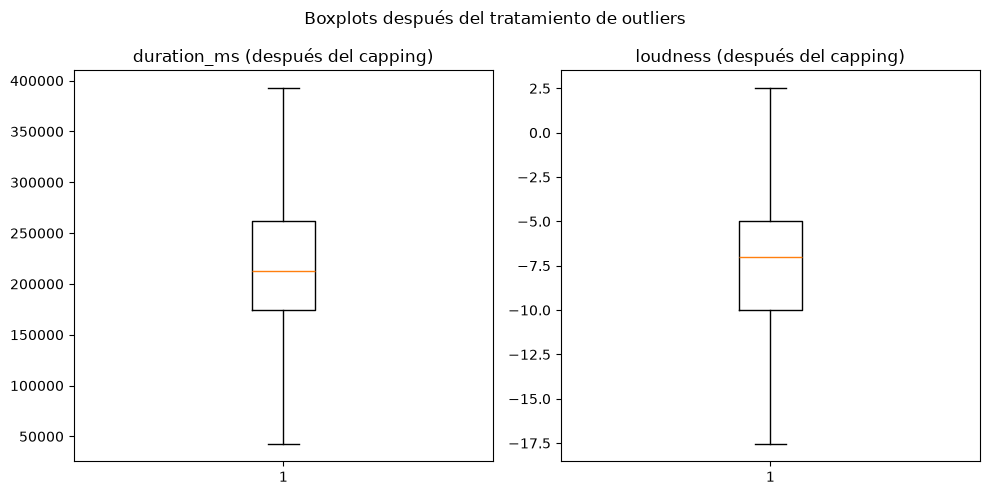

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].boxplot(df['duration_ms'], vert=True)
axs[0].set_title('duration_ms (después del capping)')

axs[1].boxplot(df['loudness'], vert=True)
axs[1].set_title('loudness (después del capping)')

plt.suptitle('Boxplots después del tratamiento de outliers')
plt.tight_layout()
plt.show()

**Conclusión:** al comparar con los boxplots del punto 3.4, se observa que tras el capping ya no aparecen puntos marcados como atípicos fuera de los bigotes — los valores extremos quedaron "recortados" al límite permitido por IQR, sin eliminar registros y sin distorsionar la mediana ni el rango central de la variable.

## 4. Análisis de correlación entre variables

In [18]:
cols_corr = cols_numericas + ['popularity']
correlacion = df[cols_corr].corr(method='pearson')
correlacion.round(2)

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,popularity
duration_ms,1.00,-0.07,0.10,0.02,-0.09,-0.16,0.11,0.00,-0.18,0.04,0.01
danceability,-0.07,1.00,0.13,0.21,0.11,-0.17,-0.19,-0.13,0.48,-0.07,0.04
energy,0.10,0.13,1.00,0.79,0.14,-0.73,-0.18,0.18,0.26,0.24,0.00
loudness,0.02,0.21,0.79,1.00,0.06,-0.60,-0.39,0.08,0.26,0.20,0.06
speechiness,-0.09,0.11,0.14,0.06,1.00,-0.00,-0.09,0.21,0.04,0.01,-0.04
acousticness,-0.16,-0.17,-0.73,-0.60,-0.00,1.00,0.10,-0.02,-0.11,-0.21,-0.03
instrumentalness,0.11,-0.19,-0.18,-0.39,-0.09,0.10,1.00,-0.08,-0.32,-0.04,-0.10
liveness,0.00,-0.13,0.18,0.08,0.21,-0.02,-0.08,1.00,0.02,0.01,-0.01
valence,-0.18,0.48,0.26,0.26,0.04,-0.11,-0.32,0.02,1.00,0.07,-0.04
tempo,0.04,-0.07,0.24,0.20,0.01,-0.21,-0.04,0.01,0.07,1.00,0.01


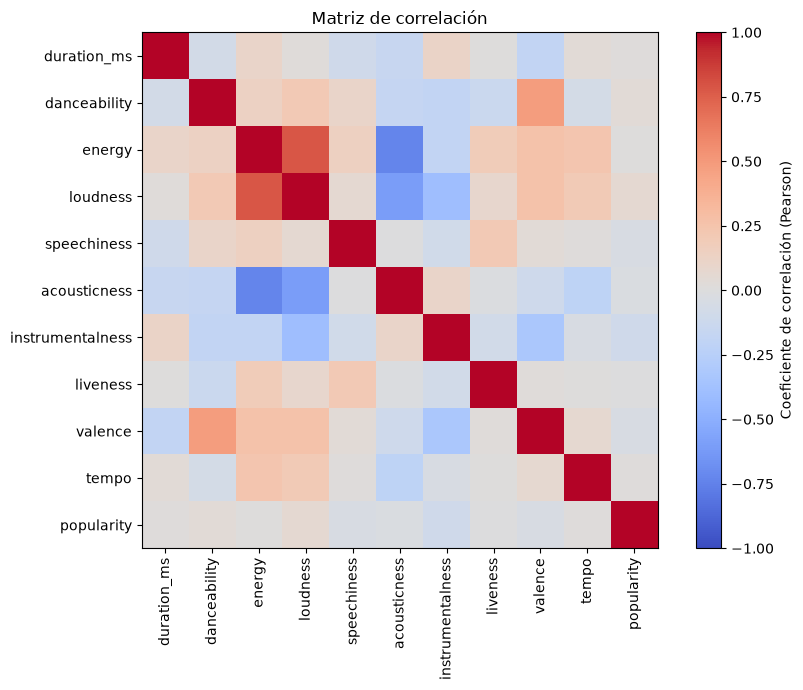

In [19]:
plt.figure(figsize=(9,7))
plt.imshow(correlacion, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Coeficiente de correlación (Pearson)')
plt.xticks(range(len(cols_corr)), cols_corr, rotation=90)
plt.yticks(range(len(cols_corr)), cols_corr)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

**Hallazgos:**

1. **Ninguna variable de audio se correlaciona fuertemente con `popularity`** (la más alta es `instrumentalness` con apenas -0,10). Esto sugiere que la popularidad de una canción depende más del artista, la promoción o el contexto (factores que no capturan estas variables) que de sus características sonoras puras. Es un hallazgo importante para las conclusiones del proyecto: un modelo basado solo en audio difícilmente tendrá un rendimiento alto por sí solo.
2. **`energy` está altamente correlacionada con `loudness` (0,79)** y con **`acousticness` (-0,73)**: canciones más energéticas tienden a ser más fuertes y menos acústicas — es información redundante.
3. `loudness` y `acousticness` también se correlacionan (-0,60), pero en menor grado, por lo que ambas se conservan.

**Decisión:** se elimina `energy` por ser redundante con `loudness` y `acousticness`, reduciendo dimensionalidad sin perder información relevante (esas dos variables ya capturan lo mismo que `energy` explicaba).

In [20]:
df = df.drop(columns=['energy'])
df.columns.tolist()

['popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'track_genre']

## 5. Escalamiento y codificación de variables

### 5.1 Escalamiento de variables numéricas

Como en el punto 3 vimos que varias variables tienen outliers naturales y legítimos (no errores), se usa **RobustScaler**, que se basa en la mediana y el rango intercuartílico — es la opción más adecuada cuando se sabe que hay valores atípicos que no se van a eliminar, evitando que estos distorsionen el escalamiento (a diferencia de StandardScaler, que usa la media y se ve afectada por ellos).

In [21]:
cols_a_escalar = ['duration_ms','danceability','loudness','speechiness',
                   'acousticness','instrumentalness','liveness','valence','tempo']

scaler = RobustScaler()
df[cols_a_escalar] = scaler.fit_transform(df[cols_a_escalar])
df[cols_a_escalar].describe()

,duration_ms,danceability,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,0.109779,-0.055230,-0.187275,0.735640,0.251093,3.183837,0.466016,0.023802,0.007218
std,0.836408,0.726118,0.800826,2.175563,0.572230,6.317446,1.087873,0.612910,0.730309
min,-1.944190,-2.426778,-2.100599,-1.006173,-0.290828,-0.000849,-0.754286,-1.096927,-2.262988
25%,-0.444190,-0.518828,-0.600599,-0.267490,-0.261745,-0.000849,-0.194286,-0.482270,-0.555205
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.555810,0.481172,0.399401,0.732510,0.738255,0.999151,0.805714,0.517730,0.444795
max,2.055810,1.694561,1.899401,18.849794,1.423163,20.407314,4.960000,1.255319,2.990660


### 5.2 Codificación de variables categóricas

- **`explicit`** es booleana → se convierte directamente a 0/1.
- **`mode`** ya viene como 0/1 (Menor/Mayor) — no requiere transformación adicional.
- **`key`** representa una tonalidad musical (Do, Do#, Re...). Aunque venga como número del 0 al 11, **no tiene un orden real** (Do no es "menos" que Re): es nominal, así que corresponde **One-Hot Encoding**.
- **`track_genre`** también es nominal (114 categorías, sin orden entre ellas) → también corresponde **One-Hot Encoding**, aunque esto aumentará bastante la dimensionalidad del dataset (114 columnas nuevas). Es una limitación conocida del One-Hot con muchas categorías, pero es la técnica vista en el curso para variables nominales.

In [22]:
df['explicit'] = df['explicit'].astype(int)

df = pd.get_dummies(df, columns=['key', 'track_genre'], drop_first=False, dtype=int)
print(df.shape)
df.head()

(114000, 139)


,popularity,duration_ms,explicit,danceability,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,73,0.203111,0,0.401674,0.051497,0,1.936214,-0.235416,-0.000828,1.291429,...,0,0,0,0,0,0,0,0,0,0
1,55,-0.723879,0,-0.669456,-2.042116,1,0.563786,1.299260,-0.000736,-0.177143,...,0,0,0,0,0,0,0,0,0,0
2,57,-0.023788,0,-0.594142,-0.544910,1,0.139918,0.070556,-0.000849,-0.085714,...,0,0,0,0,0,0,0,0,0,0
3,71,-0.125492,0,-1.313808,-2.100599,1,-0.259259,1.266563,0.000594,0.000000,...,0,0,0,0,0,0,0,0,0,0
4,82,-0.160716,0,0.158996,-0.534331,1,0.076132,0.516262,-0.000849,-0.280571,...,0,0,0,0,0,0,0,0,0,0


**Resultado:** el dataset creció bastante en número de columnas después del One-Hot Encoding (de 15 a 139), principalmente por las 114 categorías de género. Para un modelo real, en etapas posteriores del proyecto podría evaluarse reducir esta dimensionalidad (por ejemplo, agrupando géneros similares), pero para esta etapa de preprocesamiento se deja así, siguiendo la técnica correspondiente al tipo de variable.

## 6. Exportar dataset procesado

Se guarda el dataset ya preprocesado (sin valores faltantes ni variables redundantes, con outliers tratados, escalamiento y codificación aplicados), listo para la etapa de modelación supervisada.

In [24]:
df.to_csv('../data/processed/spotify_dataset_procesado.csv', index=False)
print("Dataset final:", df.shape)

Dataset final: (114000, 139)


## 7. Conclusiones

El preprocesamiento del dataset de Spotify permitió dejarlo listo para la etapa de modelación, pero también arrojó hallazgos relevantes para el negocio:

- **La popularidad no depende fuertemente de las características de audio.** Ninguna variable (danceability, energy, acousticness, etc.) mostró una correlación mayor a 0,10 con `popularity`. Esto sugiere que factores externos —como el artista, la promoción, la fecha de lanzamiento o el contexto cultural— probablemente influyen más en qué tan popular es una canción que su sonido en sí mismo. Es un hallazgo importante para las preguntas de negocio: un modelo entrenado solo con estas variables de audio probablemente tendrá un poder predictivo limitado.
- **Los datos venían relativamente "limpios"**, pero con problemas sutiles: no había valores nulos explícitos, pero sí valores imposibles disfrazados de números (tempo y duración en 0), que hubieran pasado desapercibidos sin revisar el significado real de cada variable.
- **La redundancia entre variables de audio** (energy con loudness y acousticness) confirma que varias de estas métricas miden aspectos parecidos del sonido, por lo que reducirlas no le quita información real al análisis.
- **El género musical (`track_genre`) es la variable categórica más compleja de manejar**: al tener 114 categorías, el One-Hot Encoding aumentó considerablemente la dimensionalidad del dataset. Para las siguientes etapas del proyecto (modelación), esto es algo a tener en cuenta al elegir qué algoritmos usar.

En síntesis, el dataset queda preparado técnicamente, pero el análisis sugiere que el equipo debería considerar incorporar otras fuentes de información (fecha de lanzamiento, seguidores del artista, etc.) si se busca un modelo de popularidad con buen desempeño, ya que las variables puramente musicales por sí solas no parecen ser suficientes.